In [584]:
import numpy as np
from hackrf import HackRF
import time
import matplotlib.pyplot as plt
from datetime import datetime
import os
from scipy.signal import stft
from scipy.signal import butter, filtfilt
from numpy.fft import fftshift

fs = 5_000_000  # Hz sampling rate
symbol_rate = 100_000  # Hz symbol rate
symbols_per_block = 1000 # from the transmitted waveform, 100 sym on, 900 sym off
fc = 10.1e6  # Hz center frequency (receive frequency)
ftone = 10e6  # Hz tone frequency (transmit frequency)
samples_per_block = fs // symbol_rate * symbols_per_block


In [585]:
# Setup save directory and timestamped filename for binary .dat (complex64 interleaved)
main_dir = "/home/cubesat/Cubesat/Proj1/data/iq"

# get newest file
dat_file = max(
    (os.path.join(main_dir, f) for f in os.listdir(main_dir)),
    key=os.path.getmtime
)

delta_f = ftone - fc           # TX - RX (Hz). For TX=1.0 MHz, RX=1.1 MHz => -100 kHz

# --- Load interleaved int8 IQ: I0,Q0,I1,Q1,... ---
raw = np.fromfile(dat_file, dtype=np.int8)

# drop first 2 ms as hackrf can be unstable at start
raw = raw[fs//1000*2:]  # drop first 2 ms 

# Convert to complex64
iq = raw[0::2].astype(np.float32) + 1j * raw[1::2].astype(np.float32)

# remove DC offset
iq = iq - np.mean(iq)


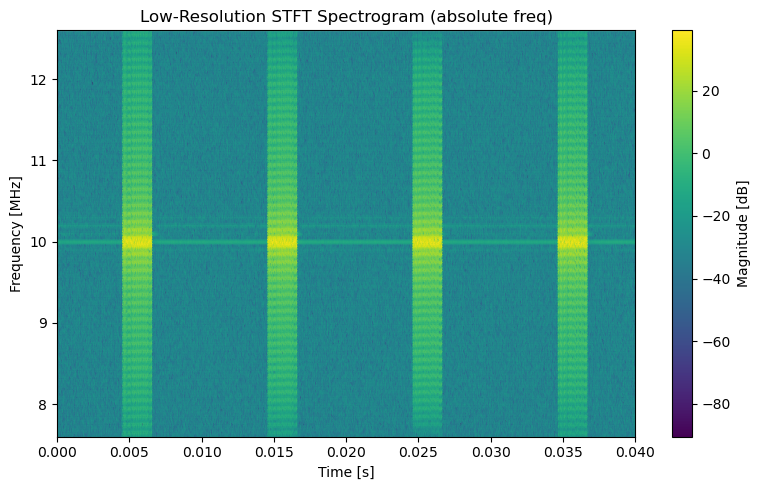

STFT shape = (256, 1564), time frames = 1564, freq bins = 256


In [586]:
# Downsample and shorten for speed
# iq_ds = iq[start_idx-100_000:start_idx+400_000]      # only first 200k samples, every 20th
iq_ds = iq[:200_000]

# STFT parameters
nperseg = 256
noverlap = nperseg // 2
window = 'hann'

# Compute STFT
f, t, Zxx = stft(iq_ds, fs=fs, window=window, nperseg=nperseg,
                 noverlap=noverlap, return_onesided=False)

# Shift and convert to dB
Zxx_shift = fftshift(Zxx, axes=0)
f_shift = fftshift(f)
# Convert to absolute frequency by adding center_freq (if set above)
f_shift_abs = fc + f_shift
Sxx = 20 * np.log10(np.abs(Zxx_shift) + 1e-12)

# Plot
plt.figure(figsize=(8,5))
plt.pcolormesh(t, f_shift_abs/1e6, Sxx, shading='gouraud', cmap='viridis')
plt.xlabel('Time [s]')
plt.ylabel('Frequency [MHz]')
plt.title('Low-Resolution STFT Spectrogram (absolute freq)')
plt.colorbar(label='Magnitude [dB]')
# Set y-limits centered on center_freq if available
plt.ylim((fc - fs/2)/1e6, (fc + fs/2)/1e6)
plt.tight_layout()
plt.show()   

print(f"STFT shape = {Sxx.shape}, time frames = {len(t)}, freq bins = {len(f)}")


In [590]:
iq_block = iq[:samples_per_block] # take one block of samples (1000 symbols) 100 on 900 off

# -- shift energy near ftone to 0 Hz --
f_offset = ftone - fc  # Hz
n = np.arange(len(iq_block), dtype=np.float64)
lo = np.exp(-1j * 2*np.pi * f_offset * n / fs)
bb = iq_block * lo

sps = int(fs / symbol_rate)   # 50
M = sps                       # moving-average length (try 50)

# Low-pass filter via moving average
h = np.ones(M, dtype=np.float64) / M
bb_lp = np.convolve(bb, h, mode="same")


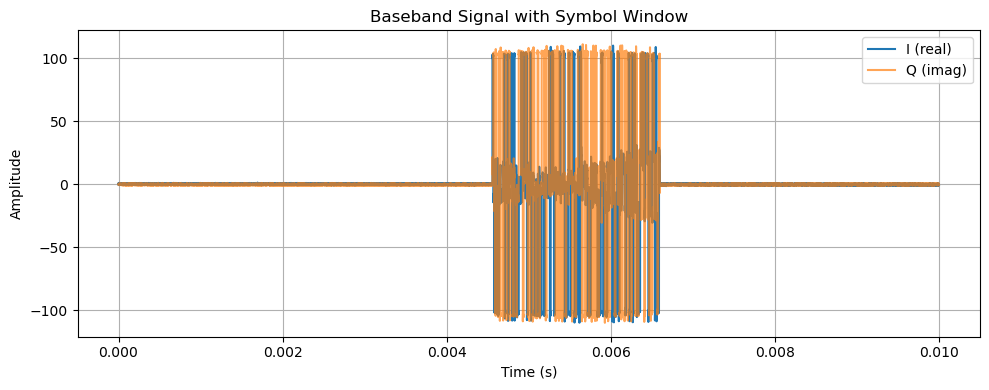

In [591]:
# plot the bb signal over interval
t_bb = np.arange(len(bb)) / fs
plt.figure(figsize=(10, 4))
plt.plot(t_bb, np.real(bb), label="I (real)")
plt.plot(t_bb, np.imag(bb), label="Q (imag)", alpha=0.7)
# plt.axvline(win_start / fs, color="g", linestyle="--", label="Symbol window")
# plt.axvline(win_stop / fs, color="g", linestyle="--", alpha=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Baseband Signal with Symbol Window")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [592]:
# Step 1: Calculate power of low-pass filtered signal
p = np.abs(bb_lp)**2


#(no step 2 of smoothing, as the moving average already smooths the power)

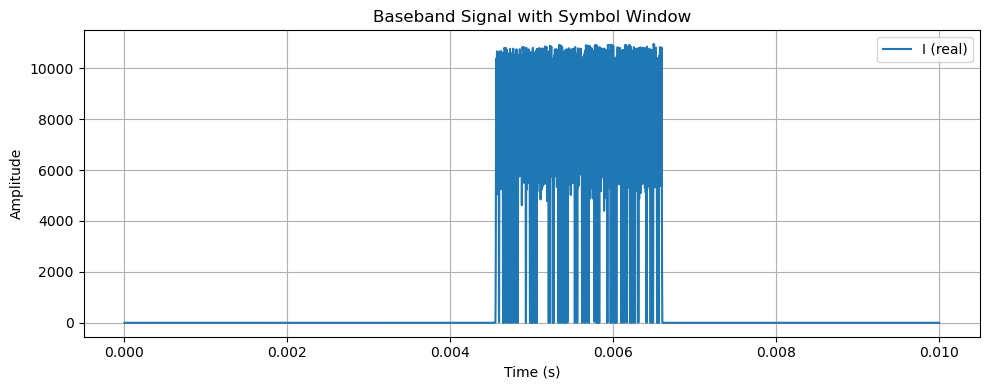

In [594]:
# plot the bb signal over interval
t_bb = np.arange(len(p)) / fs
plt.figure(figsize=(10, 4))
plt.plot(t_bb, p, label="I (real)")
# plt.axvline(win_start / fs, color="g", linestyle="--", label="Symbol window")
# plt.axvline(win_stop / fs, color="g", linestyle="--", alpha=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Baseband Signal with Symbol Window")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [595]:
# 1) Simple threshold from scaling floor (might not be ideal outside lab setup)
thr = 0.1 * np.max(p)   # 30% of peak power (adjust 0.2–0.5 if needed)

# 2) Skip first symbol worth of samples (peak can be in first symbol due to filter transient), then find first crossing of threshold
offset = sps
start_coarse = offset + np.where(p[offset:] > thr)[0][0]

# # 3) Refine: snap to local maximum in small window
# search_len = sps // 2
# start_idx = start_coarse + np.argmax(p[start_coarse:start_coarse + search_len])
start_idx = start_coarse
print("start_idx:", start_idx)
print("time (s):", start_idx / fs)

start_idx: 22778
time (s): 0.0045556


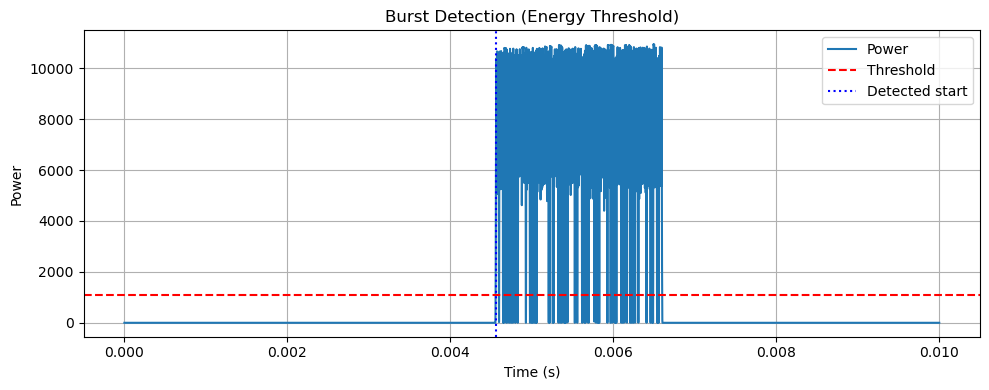

In [596]:
t = np.arange(len(p)) / fs

plt.figure(figsize=(10, 4))
plt.plot(t, p, label="Power")
plt.axhline(thr, color="r", linestyle="--", label="Threshold")

start_time = start_idx / fs 
plt.axvline(start_time, color="b", linestyle=":", label="Detected start")

plt.xlabel("Time (s)")
plt.ylabel("Power")
plt.title("Burst Detection (Energy Threshold)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Part 2: Phase Demodulation

With the start_idx of symbol calculated, we can now simply take average of s_bb(t) over interval and get our phase  

In [600]:
bb = bb - np.mean(bb) # remove any residual DC offset

# Average over the middle 50% of each symbol
shift_symbols = 0
view_start = shift_symbols*sps + start_idx + sps//8
view_stop  = shift_symbols*sps + start_idx + 100*7*sps//8

sym_est = np.mean(bb[view_start:view_stop])


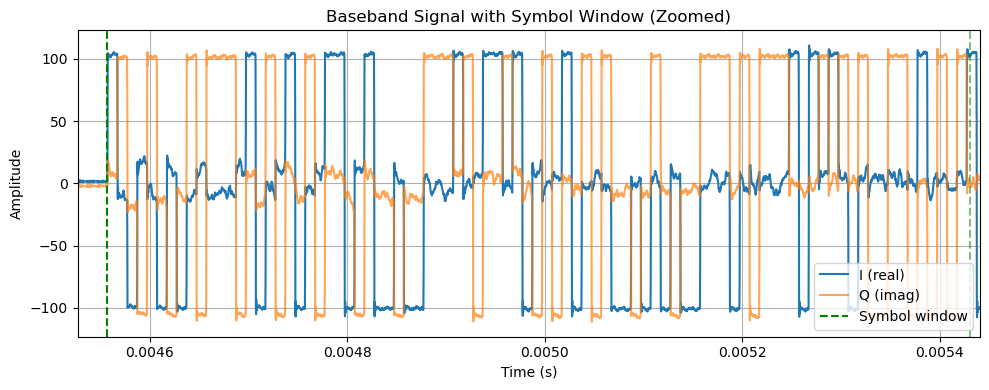

In [601]:
# plot the bb signal with zoom on the symbol window
plt.figure(figsize=(10, 4))
plt.plot(t_bb, np.real(bb), label="I (real)")
plt.plot(t_bb, np.imag(bb), label="Q (imag)", alpha=0.7)
plt.axvline(view_start / fs, color="g", linestyle="--", label="Symbol window")
plt.axvline(view_stop / fs, color="g", linestyle="--", alpha=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Baseband Signal with Symbol Window (Zoomed)")
plt.legend()
plt.grid(True)

# Zoom in on the symbol window
zoom_start = (view_start - 3*sps) / fs
zoom_stop = (view_stop + sps) / fs
plt.xlim(zoom_start, zoom_stop)

plt.tight_layout()
plt.show()

There will be an arbitrary 90*k deg phase shift to proper I and Q values

Create function to properly map symbol values to bits by using pilot sequence which would be (1,1), (-1,1), (-1,-1), (1,1) for QPSK as input, takes first four symbols obtained. 

In [ ]:
# determines mapping based on first symbol, then checks that the next three symbols match the expected pilot sequence, if not give error message.
def determine_mapping(pilot_symbols):    
    # QPSK constellation points
    constellation = np.array([1+1j, -1+1j, -1-1j, 1-1j]) / np.sqrt(2)
    bits = np.array([[1,1], [0,1], [0,0], [1,0]])  # mapping: 00->-1-j, 01->-1+j, 10->1-j, 11->1+j
    
    pilot_sequence = constellation
    mapping_constellation = constellation.copy() # will be reordered based on pilot sequence
    mapping = bits.copy() # will be reordered to match constellation mapping
    
    # find nearest constellation point for first symbol
    distances = np.abs(pilot_symbols[0] - constellation)
    idx = np.argmin(distances)
    
    # determine mapping based on pilot sequence, 
    print(f"First pilot symbol: {pilot_symbols[0]}, nearest constellation point: {constellation[idx]}")
    first_symbol = constellation[idx]
    if first_symbol == pilot_sequence[0]:
        mapping_constellation = mapping_constellation
        mapping = mapping
    elif first_symbol == pilot_sequence[1]: # first is (-1,1) => mapping is shifted by 1
        # shift mapping by 1
        mapping_constellation = np.roll(mapping_constellation, 1, axis=0)
        mapping = np.roll(mapping, 1, axis=0)
    elif first_symbol == pilot_sequence[2]: # first is (-1,-1) => mapping is shifted by 2
        mapping_constellation = np.roll(mapping_constellation, 2, axis=0)
        mapping = np.roll(mapping, 2, axis=0)
    elif first_symbol == pilot_sequence[3]: # first is (1,-1) => mapping is shifted by 3
        mapping_constellation = np.roll(mapping_constellation, 3, axis=0)
        mapping = np.roll(mapping, 3, axis=0)
    
    # check that the next three symbols match the expected pilot sequence
    for i in range(1, len(pilot_symbols)):
        distances = np.abs(pilot_symbols[i] - constellation)
        idx = np.argmin(distances)
        # use mapping to get expected constellation point for this symbol
        expected_symbol = mapping_constellation[idx]
        if pilot_sequence[i] != expected_symbol:
            print(f"Warning: Pilot symbol {i+1} does not match expected value based on mapping. Got {expected_symbol}, expected {pilot_sequence[i]}")
            
    return mapping
        

In [566]:
# function to map symbol value to bits (for QPSK) by nearest constellation point and mapping determined from pilot sequence
def symbol_to_bits(sym, mapping):
    # QPSK constellation points
    constellation = np.array([1+1j, -1+1j, -1-1j, 1-1j]) / np.sqrt(2)
    
    # find nearest constellation point
    distances = np.abs(sym - constellation)
    idx = np.argmin(distances)
    
    return mapping[idx]

In [572]:
# obtain first 100 symbols
num_symbols = 200
symbol_values = []
for i in range(num_symbols):
    sym_win_start = start_idx + i * sps + sps//8
    sym_win_stop = start_idx + (i + 1) * sps - sps//8
    sym_est = np.mean(bb[sym_win_start:sym_win_stop])
    symbol_values.append(sym_est)

In [573]:
# run the mapping determination on the first 4 symbols
pilot_symbols = symbol_values[:4]
mapping = determine_mapping(pilot_symbols)

# print mapping
print("Determined bit mapping for constellation points:")
constellation = np.array([1+1j, -1+1j, -1-1j, 1-1j]) / np.sqrt(2)
for i in range(len(constellation)):
    print(f"Symbol: {constellation[i]}, Bits: {mapping[i]}")

First pilot symbol: (68.26851892756252-68.66909627133796j), nearest constellation point: (0.7071067811865475-0.7071067811865475j)
Determined bit mapping for constellation points:
Symbol: (0.7071067811865475+0.7071067811865475j), Bits: [0 1]
Symbol: (-0.7071067811865475+0.7071067811865475j), Bits: [0 0]
Symbol: (-0.7071067811865475-0.7071067811865475j), Bits: [1 0]
Symbol: (0.7071067811865475-0.7071067811865475j), Bits: [1 1]


In [574]:
# with mapping, decode all symbols to bits
decoded_bits = []
for sym in symbol_values:
    bits = symbol_to_bits(sym, mapping)
    decoded_bits.append(bits)

In [575]:
# convert using ascii encoding (for example, 2 bits per symbol => 4 symbols per byte)
# dont include pilot first four symbols
data_bits = np.array(decoded_bits[4:]).flatten()  # flatten to 1D array
# group into bytes (8 bits)
num_bits_per_byte = 8
num_bytes = len(data_bits) // num_bits_per_byte
data_bytes = []
for i in range(num_bytes):
    byte_bits = data_bits[i*num_bits_per_byte:(i+1)*num_bits_per_byte]
    byte_value = 0
    for bit in byte_bits:
        byte_value = (byte_value << 1) | bit
    data_bytes.append(byte_value)
    
# convert to ascii string
data_string = ''.join(chr(b) for b in data_bytes)
print("Decoded data string:")
print(data_string)


Decoded data string:
Hello, World! Testing to see if this really works
